The goal of this project is to develop a 3D image segmentation model that can effectively identify and segment specific medical structures within the constraints of limited computational resources. The original datasets combined had a total size in excess of 50 GB, and in order to replicate this experiment with Google Colab and a free Google Drive account I decided to only to train on one of the datasets. This dataset is approximately 8.5 GB large.

Since I ran this code through Google Colab all of the following packages were already installed with the exception of segmentation_models_pytorch.

In [ ]:
!pip install segmentation_models_pytorch
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.checkpoint as checkpoint
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
import tarfile
import os
import nibabel as nib
from collections import OrderedDict
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import time
from google.colab import drive

The data stems from the Medical Segmentation Decathlon (http://medicaldecathlon.com/). As described in their paper (https://arxiv.org/pdf/1902.09063) they have multiple datasets. I chose dataset 6 because it was the largest dataset that did not involve multiclass image segmentation. The images are formatted to NIfTI images and therefore need to be converted to, in our case, PyTorch tensors.

In [ ]:
# Define the path to the uploaded .tar file and the extraction directory
tar_path = '/content/drive/MyDrive/Task06_Lung.tar'
extraction_path = 'Task06_Lung/'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Extract the .tar file
with tarfile.open(tar_path, 'r') as tar:
    tar.extractall(path=extraction_path)

# List the contents of the extracted directory
extracted_files = os.listdir(extraction_path)
# Load NIfTI images
def load_nifti_image(file_path):
    try:
        img = nib.load(file_path)
        data = img.get_fdata()
        return data
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")
        return None

The following code deals with pre-processing. I originally wrote some of the code for other datasets from the decathlon and it is possible that certain parts of the pre-processing is not necessary for this dataset in particular. There are 3 main parts to the pre-processing I used:

Padding: Some of the images had slightly different dimensions. This was simply solved by padding all the images with the minimal amount of zeroes needed to ensure they were all of the same size. This process is made redundant by the next pre-processing step, but I include it since it was essential for initial models.

Image re-sizing:
Certain models I initially tried would not run due to the dataset being too large, and I thus resized the images through the interpolate function from torch.nn.functional. Resizing was essential to manage memory constraints and ensure that the model could be trained within the available computational resources. It is worth noting that this was done on both the images and labels of both the training and test set.

Image augmentation:
This is a classic computer vision method of improving small datasets by generating new images by simply transforming old images in ways that should still be classifiable by the algorithm. While I used this for many trial models, I did not find any considerable improvement in model accuracy. I expect this is because the images from the dataset are all very neatly gathered, with all the patients lying in similar positions, thus eliminating the point of introducing new images that have major transformations.

In [ ]:
def resize_image(image, target_shape):
    # Resize the image to the target shape using trilinear interpolation
    image = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
    resized_image = F.interpolate(image, size=target_shape, mode='trilinear', align_corners=False)
    return resized_image.squeeze()  # Remove batch and channel dimensions

# Preprocess and pad images to the target shape
def preprocess_and_pad_image(image_path, label_path, target_shape):
    img = load_nifti_image(image_path)
    lbl = load_nifti_image(label_path)

    if img is not None and lbl is not None:
        img = resize_image(img, target_shape)
        lbl = resize_image(lbl, target_shape)

        img = img.numpy()  # Convert back to numpy array
        lbl = lbl.numpy()  # Convert back to numpy array

        pad_width = [(0, max(0, target_shape[i] - img.shape[i])) for i in range(len(img.shape))]
        img = np.pad(img, pad_width, mode='constant')
        lbl = np.pad(lbl, pad_width, mode='constant')

        return img, lbl  # Return numpy arrays
    return None, None

# Define the augmentation transform
transform = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.OneOf([
        A.GridDistortion(p=0.5),
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=None, p=0.5)
    ], p=0.5),
    A.RandomBrightnessContrast(p=0),
])

class LungDataset(Dataset):
    def __init__(self, image_paths, label_paths, target_shape, transform=None):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.target_shape = target_shape
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        lbl_path = self.label_paths[idx]
        img, lbl = preprocess_and_pad_image(img_path, lbl_path, self.target_shape)

        if img is not None and lbl is not None:
            if self.transform:
                augmented = self.transform(image=img, mask=lbl)
                img = augmented['image']
                lbl = augmented['mask']
            img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # Add channel dimension
            lbl_tensor = torch.tensor(lbl, dtype=torch.float32).unsqueeze(0)  # Add channel dimension
            return img_tensor, lbl_tensor
        else:
            raise ValueError(f"Error processing file: {img_path}")

# Define paths to images and labels
main_directory = 'Task06_Lung/Task06_Lung'  # Adjust based on new dataset path
images_tr_dir = os.path.join(main_directory, 'imagesTr')
labels_tr_dir = os.path.join(main_directory, 'labelsTr')

image_paths = [os.path.join(images_tr_dir, fname) for fname in os.listdir(images_tr_dir) if not fname.startswith('._')]
label_paths = [os.path.join(labels_tr_dir, fname) for fname in os.listdir(labels_tr_dir) if not fname.startswith('._')]

# Find the maximum shape
# shapes = [load_nifti_image(path).shape for path in image_paths]
# max_shape = tuple(map(max, zip(*shapes)))

target_shape = (128, 128, 128)

# Create dataset with augmentation
dataset = LungDataset(image_paths, label_paths, target_shape, transform=False)

# Split dataset
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# Create data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

I chose to use a 3D U-net, a common choice for segmentation tasks. I include two versions that I have used. The main difference is simply size.

In [ ]:
class UNet3D(nn.Module):
    def __init__(self, in_channels, out_channels, init_features=16):
        super(UNet3D, self).__init__()
        features = init_features
        self.encoder1 = UNet3D._block(in_channels, features, name="enc1")
        self.pool1 = nn.MaxPool3d(kernel_size=2, stride=2)
        self.encoder2 = UNet3D._block(features, features * 2, name="enc2")
        self.pool2 = nn.MaxPool3d(kernel_size=2, stride=2)
        self.encoder3 = UNet3D._block(features * 2, features * 4, name="enc3")
        self.pool3 = nn.MaxPool3d(kernel_size=2, stride=2)
        self.encoder4 = UNet3D._block(features * 4, features * 8, name="enc4")
        self.pool4 = nn.MaxPool3d(kernel_size=2, stride=2)

        self.bottleneck = UNet3D._block(features * 8, features * 16, name="bottleneck")

        self.upconv4 = nn.ConvTranspose3d(
            features * 16, features * 8, kernel_size=2, stride=2
        )
        self.decoder4 = UNet3D._block((features * 8) * 2, features * 8, name="dec4")
        self.upconv3 = nn.ConvTranspose3d(
            features * 8, features * 4, kernel_size=2, stride=2
        )
        self.decoder3 = UNet3D._block((features * 4) * 2, features * 4, name="dec3")
        self.upconv2 = nn.ConvTranspose3d(
            features * 4, features * 2, kernel_size=2, stride=2
        )
        self.decoder2 = UNet3D._block((features * 2) * 2, features * 2, name="dec2")
        self.upconv1 = nn.ConvTranspose3d(
            features * 2, features, kernel_size=2, stride=2
        )
        self.decoder1 = UNet3D._block(features * 2, features, name="dec1")

        self.conv = nn.Conv3d(
            in_channels=features, out_channels=out_channels, kernel_size=1
        )

    def forward(self, x):
        enc1 = checkpoint.checkpoint(self.encoder1, x)
        enc2 = checkpoint.checkpoint(self.encoder2, self.pool1(enc1))
        enc3 = checkpoint.checkpoint(self.encoder3, self.pool2(enc2))
        enc4 = checkpoint.checkpoint(self.encoder4, self.pool3(enc3))

        bottleneck = checkpoint.checkpoint(self.bottleneck, self.pool4(enc4))

        dec4 = self.upconv4(bottleneck)
        dec4 = self.center_crop(dec4, enc4.shape[2:])
        enc4 = self.center_crop(enc4, dec4.shape[2:])
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = checkpoint.checkpoint(self.decoder4, dec4)

        dec3 = self.upconv3(dec4)
        dec3 = self.center_crop(dec3, enc3.shape[2:])
        enc3 = self.center_crop(enc3, dec3.shape[2:])
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = checkpoint.checkpoint(self.decoder3, dec3)

        dec2 = self.upconv2(dec3)
        dec2 = self.center_crop(dec2, enc2.shape[2:])
        enc2 = self.center_crop(enc2, dec2.shape[2:])
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = checkpoint.checkpoint(self.decoder2, dec2)

        dec1 = self.upconv1(dec2)
        dec1 = self.center_crop(dec1, enc1.shape[2:])
        enc1 = self.center_crop(enc1, dec1.shape[2:])
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = checkpoint.checkpoint(self.decoder1, dec1)

        output = self.conv(dec1)

        return output

    @staticmethod
    def _block(in_channels, features, name):
        return nn.Sequential(
            OrderedDict(
                [
                    (name + "conv1", nn.Conv3d(in_channels, features, kernel_size=3, padding=1, bias=False)),
                    (name + "norm1", nn.BatchNorm3d(features)),
                    (name + "relu1", nn.ReLU(inplace=True)),
                    (name + "conv2", nn.Conv3d(features, features, kernel_size=3, padding=1, bias=False)),
                    (name + "norm2", nn.BatchNorm3d(features)),
                    (name + "relu2", nn.ReLU(inplace=True)),
                ]
            )
        )

    def center_crop(self, layer, target_size):
        _, _, layer_depth, layer_height, layer_width = layer.size()
        diff_depth = (layer_depth - target_size[0]) // 2
        diff_height = (layer_height - target_size[1]) // 2
        diff_width = (layer_width - target_size[2]) // 2
        return layer[:, :, diff_depth:diff_depth + target_size[0], diff_height:diff_height + target_size[1], diff_width:diff_width + target_size[2]]

# Define the simplified UNet3D model
class SimpleUNet3D(nn.Module):
    def __init__(self, in_channels, out_channels, init_features=8):
        super(SimpleUNet3D, self).__init__()
        features = init_features
        self.encoder1 = SimpleUNet3D._block(in_channels, features, name="enc1")
        self.pool1 = nn.MaxPool3d(kernel_size=2, stride=2)
        self.encoder2 = SimpleUNet3D._block(features, features * 2, name="enc2")
        self.pool2 = nn.MaxPool3d(kernel_size=2, stride=2)

        self.bottleneck = SimpleUNet3D._block(features * 2, features * 4, name="bottleneck")

        self.upconv2 = nn.ConvTranspose3d(
            features * 4, features * 2, kernel_size=2, stride=2
        )
        self.decoder2 = SimpleUNet3D._block((features * 2) * 2, features * 2, name="dec2")
        self.upconv1 = nn.ConvTranspose3d(
            features * 2, features, kernel_size=2, stride=2
        )
        self.decoder1 = SimpleUNet3D._block(features * 2, features, name="dec1")

        self.conv = nn.Conv3d(
            in_channels=features, out_channels=out_channels, kernel_size=1
        )

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))

        bottleneck = self.bottleneck(self.pool2(enc2))

        dec2 = self.upconv2(bottleneck)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)

        return self.conv(dec1)

    @staticmethod
    def _block(in_channels, features, name):
        return nn.Sequential(
            OrderedDict(
                [
                    (name + "conv1", nn.Conv3d(in_channels, features, kernel_size=3, padding=1, bias=False)),
                    (name + "norm1", nn.BatchNorm3d(features)),
                    (name + "relu1", nn.ReLU(inplace=True)),
                    (name + "conv2", nn.Conv3d(features, features, kernel_size=3, padding=1, bias=False)),
                    (name + "norm2", nn.BatchNorm3d(features)),
                    (name + "relu2", nn.ReLU(inplace=True)),
                ]
            )
        )


Evaluation: To evaluate the performance of the model I used the Dice-Sørensen score. This is simply one of the evaluations used for the models in the decathlon.

Loss: In order to maximize the Dice-Sørensen score, I used a combination of Dice loss and binary cross-entropy loss. This sum has been a popular choice of loss from others for this competition.

In [ ]:
# Initialize model, loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleUNet3D(in_channels=1, out_channels=1, init_features=4).to(device)

class DiceBCELoss(nn.Module):
    def __init__(self):
        super(DiceBCELoss, self).__init__()
        self.dice_loss = smp.losses.DiceLoss(mode='binary')
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, outputs, labels):
        dice_loss = self.dice_loss(outputs, labels)
        bce_loss = self.bce_loss(outputs, labels)
        return dice_loss + bce_loss

criterion = DiceBCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)
scaler = GradScaler()  # For mixed precision training

# Training loop with mixed precision and gradient accumulation
num_epochs = 100
accumulation_steps = 1  # Adjust based on available memory
model.train()


for epoch in range(num_epochs):
    running_loss = 0.0
    optimizer.zero_grad()
    a = time.time()
    for i, (images, labels) in enumerate(train_loader):

        # Forward pass with mixed precision
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels) / accumulation_steps

        # Backward pass
        scaler.scale(loss).backward()

        # Perform optimization step after accumulating gradients
        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item() * accumulation_steps

    b = time.time()
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}", b-a)

print("Finished Training")

# Evaluation loop with mixed precision
model.eval()
total_dice = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)  # Move to GPU if available
        outputs = model(images)
        predicted = (outputs > 0.5).float()  # Binarize the output
        intersection = (predicted * labels).sum(dim=(2, 3, 4))
        union = predicted.sum(dim=(2, 3, 4)) + labels.sum(dim=(2, 3, 4))
        dice = (2.0 * intersection / union).mean()
        total_dice += dice.item()

print(f"Average Dice Score: {total_dice / len(test_loader):.4f}")

The model achieved an average Dice score of 0.4652 on the test set, which is slightly below the median score of the original competition. This discrepancy could be attributed to the constraints of computational resources and dataset size. The median score of the original competition was 0.51, with only 3 of the 19 entries scoring higher than 0.55. 

You can save your model with the following code:

In [2]:
# Save the model's state dictionary
model_save_path = "model.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Lastly, I include a plot of the training losses for the model. 

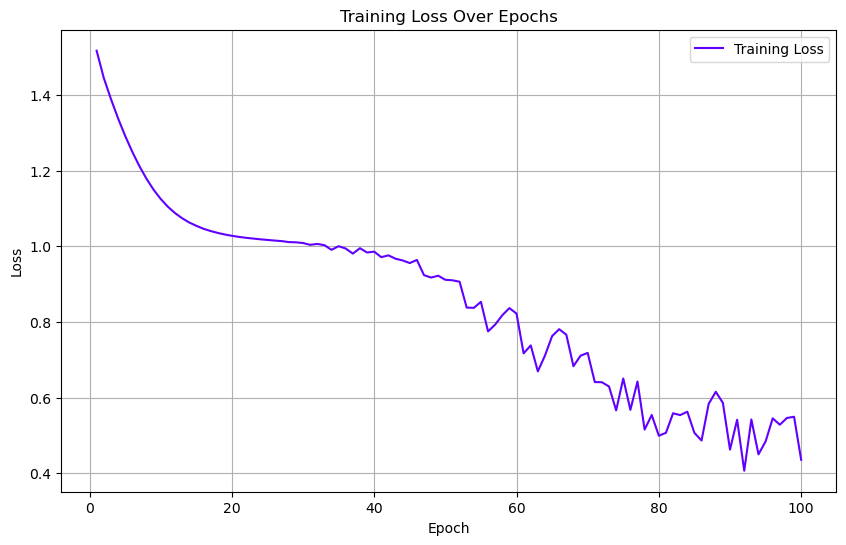

In [5]:
import matplotlib.pyplot as plt
losses = [1.5173,1.4456,1.3901,1.3391,1.2926,1.2504,1.2125,1.1789,1.1499,1.1254,1.1050,1.0882,1.0745,1.0632,1.0544,1.0466,1.0406,1.0356,1.0314,1.0279,1.0250,1.0226,1.0206,1.0186,1.0170,1.0153,1.0139,1.0113,1.0107,1.0088,1.0040,1.0064,1.0032,0.9908,1.0004,0.9942,0.9808,0.9951,0.9837,0.9860,0.9714,0.9762,0.9673,0.9627,0.9558,0.9641,0.9238,0.9175,0.9223,0.9116,0.9102,0.9065,0.8381,0.8373,0.8533,0.7751,0.7931,0.8178,0.8367,0.8223,0.7171,0.7381,0.6694,0.7113,0.7626,0.7810,0.7663,0.6831,0.7109,0.7183,0.6411,0.6407,0.6294,0.5663,0.6506,0.5676,0.6426,0.5155,0.5540,0.4992,0.5070,0.5586,0.5538,0.5628,0.5067,0.4866,0.5833,0.6155,0.5861,0.4625,0.5415,0.4067,0.5423,0.4500,0.4840,0.5452,0.5284,0.5462,0.5494,0.4356]
epochs = list(range(1, len(losses) + 1))

# Plot the loss values over epochs
plt.figure(figsize=(10, 6))
plt.plot(epochs, losses, label='Training Loss',color="#6000FF")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.legend()
plt.show()